In [4]:
# CELL — Option A baseline IVP at FN_DEFAULT, 4-panel diagnostic
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))

import cariaco_baseline_setups as cbs
import run_baseline_diagnostic as rbd

# Re-import after editing either file
importlib.reload(cbs)
importlib.reload(rbd)

# Run + extract + plot
out   = rbd.run_setup(cbs.model_baseline, cbs.model_setup_baseline)
state = rbd.extract_state(out)
fig   = rbd.plot_diagnostic(
    state,
    phyto_esd=cbs.phyto_esd, zoo_esd=cbs.zoo_esd,
    FN=cbs.FN_DEFAULT, de=cbs.DE_DEFAULT,
    save_path='fig_baseline_optA_FN267.png',
)
rbd.print_summary(state, n_classes_label=str(cbs.N_CLASSES))

KeyError: "('Inflow', 'de_label'), ('PhytoSinking', 'de'), ('PhytoSinking', 'w_sink') is/are not valid key(s) for input variables in model <xsimlab.Model (12 processes, 34 inputs)>\nCore\n    solver_type         [in] solver type to use for model\n    solver_kwargs       [in] JSON-encoded extra keyword arguments f...\nTime\n    time_input          [in] ('time',) sequence of time for which t...\nNutrient\n    value_label         [in] label / dissolved inorganic nitrogen\n    value_init          [in] initial value / dissolved inorganic ni...\nPhytoplankton\n    biomass_label       [in] label / phytoplankton biomass\n    biomass_init        [in] ('phyto',) initial value / phytoplankt...\n    phyto_esd_index     [in] ('phyto',) index / phyto size classes ...\n    phyto_esd_label     [in] broadcast label / phyto size classes (...\nZooplankton\n    biomass_label       [in] label / zooplankton biomass\n    biomass_init        [in] ('zoo',) initial value / zooplankton b...\n    zoo_esd_index   

Saved figure to: fig_baseline_optA_FN8.png

Tail-mean summary (last 1000 d):
  N             : 0.6116 mmol N m-3
  ΣP            : 1.5916 mmol N m-3
  ΣZ            : 1.9826 mmol N m-3
  Z:P ratio     : 1.246
  Alive P (>1e-6): 11 / 12
  Alive Z (>1e-6): 10 / 12


{'P_tail': array([6.19660188e-02, 6.44011763e-02, 6.69875523e-02, 6.05320514e-02,
        9.29327224e-02, 1.26449519e-01, 1.24619643e-01, 2.03252917e-01,
        1.95761496e-01, 2.31219023e-01, 3.63444074e-01, 1.72388851e-45]),
 'Z_tail': array([4.64736634e-01, 3.93588533e-01, 3.10365520e-01, 2.54618588e-01,
        2.09303896e-01, 1.55017087e-01, 1.05426891e-01, 5.99056779e-02,
        2.55851525e-02, 4.05842932e-03, 2.16407487e-31, 1.51796464e-48]),
 'N_tail': np.float64(0.6115933629335831),
 'sumP': np.float64(1.5915661935222167),
 'sumZ': np.float64(1.9826064089747077),
 'ZP_ratio': np.float64(1.245695225900155),
 'n_P_alive': 11,
 'n_Z_alive': 10}

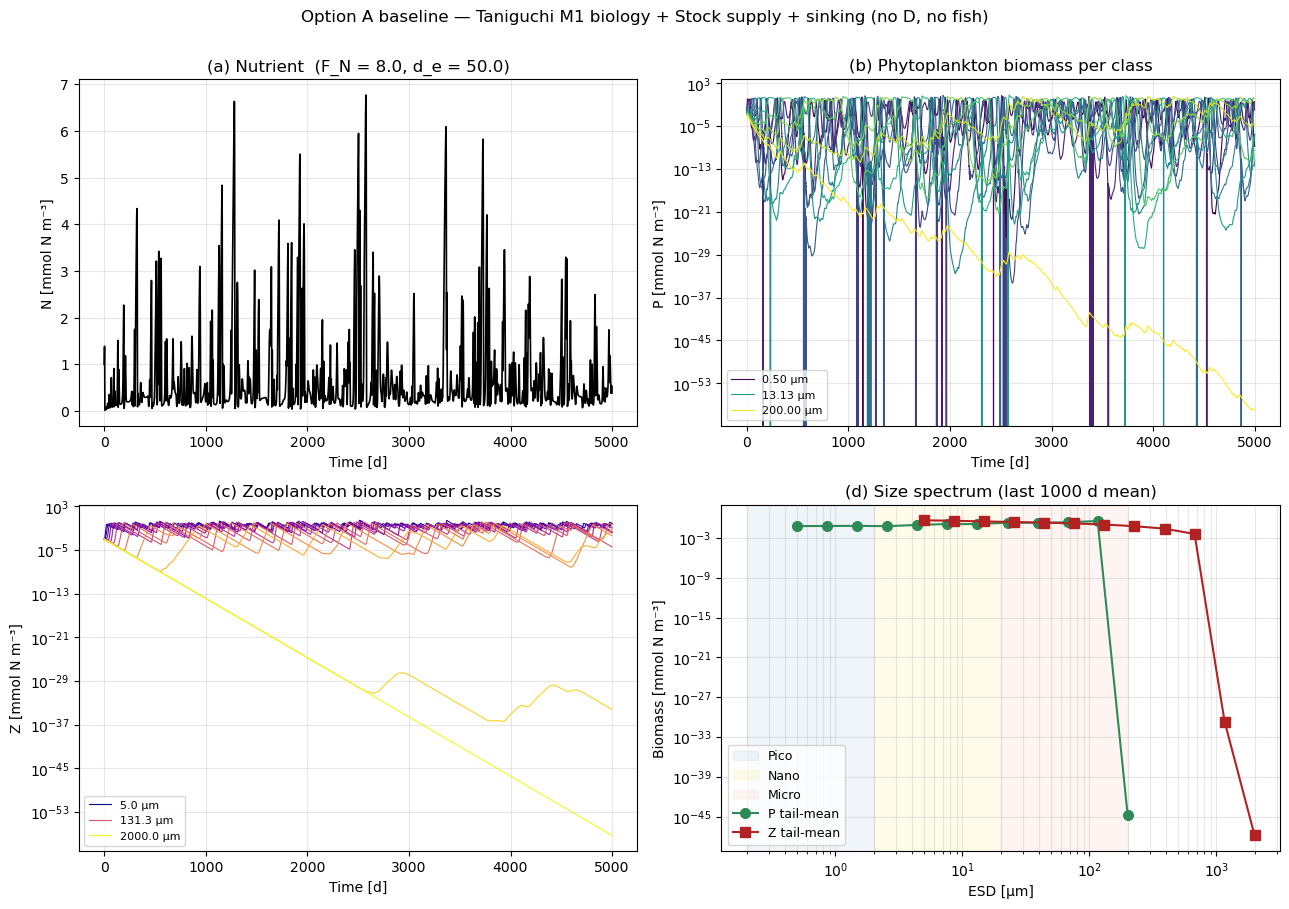

In [3]:
# CELL — same baseline at a higher F_N to populate Micro
import importlib; importlib.reload(rbd)

out = rbd.run_setup(
    cbs.model_baseline,
    cbs.model_setup_baseline,
    input_vars_override={'Supply': {'FN': 8.0}},
)
state = rbd.extract_state(out)
fig = rbd.plot_diagnostic(
    state, cbs.phyto_esd, cbs.zoo_esd,
    FN=8.0, de=cbs.DE_DEFAULT,
    save_path='fig_baseline_optA_FN8.png',
)
rbd.print_summary(state, n_classes_label=str(cbs.N_CLASSES))